In [23]:
import tensorflow as tf
from tensorflow import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Dataset Description**

The data files train.csv and test.csv contain gray-scale images of hand-drawn digits, from zero through nine.

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.

The training data set, (train.csv), has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

Each pixel column in the training set has a name like pixelx, where x is an integer between 0 and 783, inclusive. To locate this pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27, inclusive. Then pixelx is located on row i and column j of a 28 x 28 matrix, (indexing by zero).

For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

In [24]:
mnist = keras.datasets.mnist  # Default dataset for digit recognizer in mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [25]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

**Visualize data**

Visualize the first digit of the dataset

Text(0.5, 0, 'True Digit: 5')

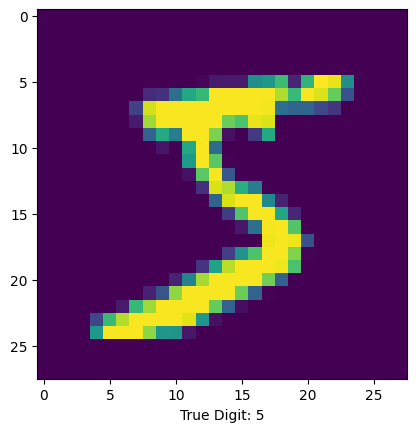

In [26]:
plt.figure()
plt.imshow(train_images[0])
plt.xlabel("True Digit: {}".format(train_labels[0]))

**Scale Data in range 0,1**

In [27]:
train_images = train_images / 255
test_images = test_images / 255

**Plot the train data**

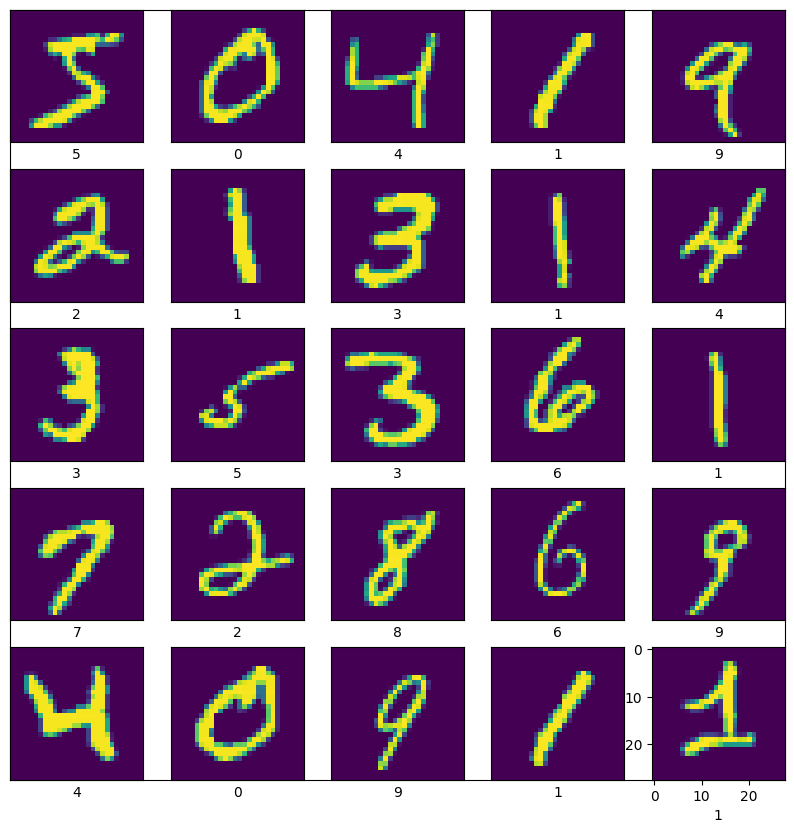

In [28]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.xticks([])
    plt.yticks([])
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i])
    plt.xlabel("{}".format(train_labels[i]))


In [29]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(64, (3,3), activation="relu"),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation="relu"), 
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [31]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9169 - loss: 0.2700
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9865 - loss: 0.0417
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9924 - loss: 0.0255
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9946 - loss: 0.0179
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9960 - loss: 0.0128


In [32]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


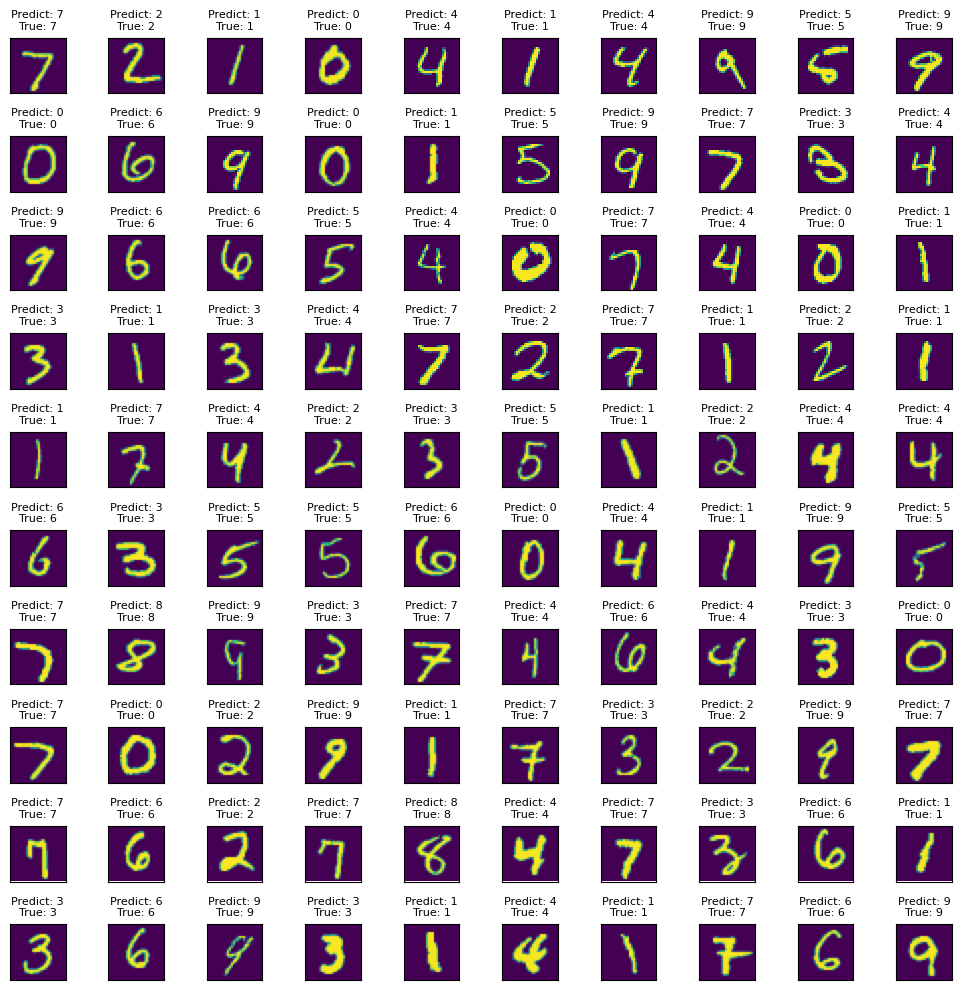

In [33]:
plt.figure(figsize=(10, 10))
for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(test_images[i])

    plt.title(
        "Predict: {}\nTrue: {}".format(
            np.argmax(predictions[i]),
            test_labels[i]
        ),
        fontsize=8  # reduce fontsize to avoid overlap
    )

plt.tight_layout()  # adjust distance between subplot to avoid overlap
plt.show()